In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Matplotlib is building the font cache; this may take a moment.


In [18]:
df = pd.read_csv('data.csv')

In [19]:
# Clean any whitespace around column names
df.columns = df.columns.str.strip()

# Convert categorical text columns (like 'M'/'F') into 0 and 1 numbers
df_encoded = pd.get_dummies(df, drop_first=True, dtype=float)

# Drop any rows with empty / missing values
df_encoded = df_encoded.dropna()

In [20]:
# X = All feature columns, y = target column (assumes target is the last column)
X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

In [21]:
# 2. Train-Test Split and Model Training
# -------------------------------------------------------------
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(train_X, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.,-0.,-0.,..., 0.,-1.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['student_id','age','studytime',...,'gender_M','parent_education_low', 'parent_education_medium']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [22]:
# Predictions on the test set
pred_y = model.predict(test_X)

print(f"R² Score: {r2_score(test_y, pred_y):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_y, pred_y)):.3f}")

R² Score: 1.000
RMSE: 0.000


c:\ml_projects\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


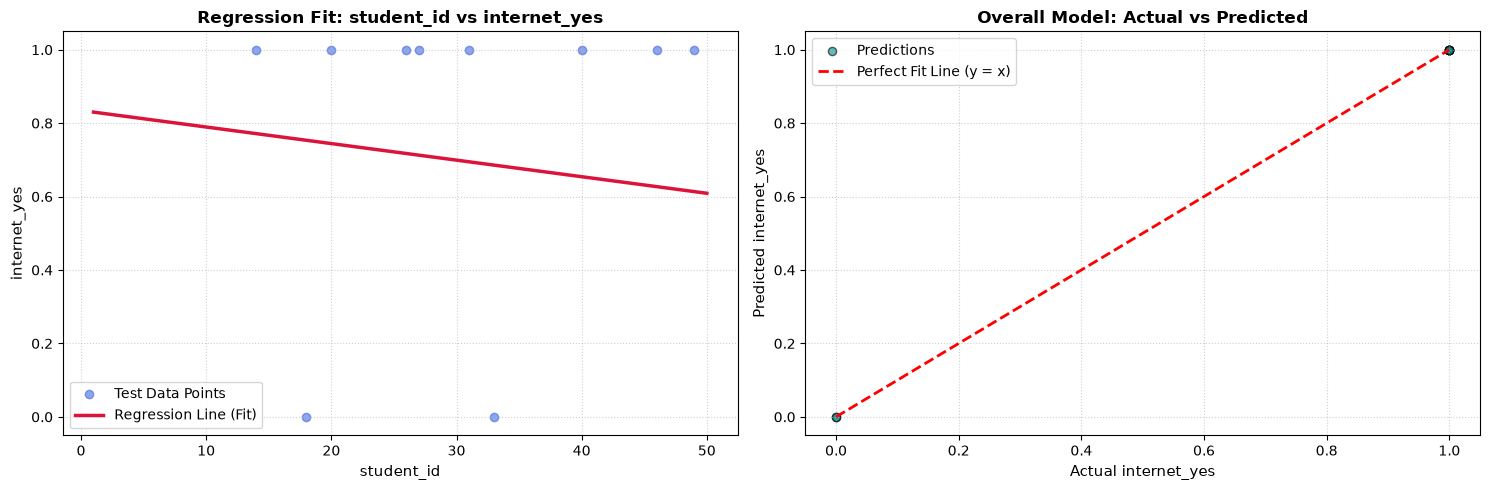

In [23]:
# -------------------------------------------------------------
# 3. Visualizations
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: 2D Best-Fit Regression Line on Primary Feature ---
# Picks the first numerical feature column to display the regression line
primary_feature_idx = 0
primary_feature_name = X.columns[primary_feature_idx]

# Train a 1D model just for this visual line
single_feature_model = LinearRegression()
single_feature_model.fit(train_X[[primary_feature_name]], train_y)

x_line = np.linspace(X[primary_feature_name].min(), X[primary_feature_name].max(), 100).reshape(-1, 1)
y_line = single_feature_model.predict(x_line)

axes[0].scatter(test_X[primary_feature_name], test_y, color='royalblue', alpha=0.6, label='Test Data Points')
axes[0].plot(x_line, y_line, color='crimson', linewidth=2.5, label='Regression Line (Fit)')
axes[0].set_title(f"Regression Fit: {primary_feature_name} vs {y.name}", fontsize=12, fontweight='bold')
axes[0].set_xlabel(primary_feature_name, fontsize=11)
axes[0].set_ylabel(y.name, fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# --- Plot 2: Actual vs. Predicted (All Features Model) ---
axes[1].scatter(test_y, pred_y, color='darkcyan', alpha=0.6, edgecolors='k', s=35, label='Predictions')
min_val = min(test_y.min(), pred_y.min())
max_val = max(test_y.max(), pred_y.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line (y = x)')

axes[1].set_title("Overall Model: Actual vs Predicted", fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"Actual {y.name}", fontsize=11)
axes[1].set_ylabel(f"Predicted {y.name}", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()